# Week 13 - Neural Networks

Learning contents:
- Convolutional Neural Network
    - Implement the LeNet-5 inspired architecture in PyTorch
- Limited labelled data
    - Rerun the LeNet-5 network with only 100 examples total
- Implement an Autoencoder and train it on the unlabelled data
- Demo: Using the Autoencoder in a multi-task learning setup to improve classification performance.

In [1]:
# Imports you will need
import torch
from math import ceil
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torch.optim import SGD
from torch import tanh, flatten
from torch.utils.data import DataLoader, random_split
from torch.nn import Conv2d, AvgPool2d, Linear, Module, ConvTranspose2d, Upsample, Tanh, Sequential
from torch.nn.functional import log_softmax, nll_loss, mse_loss

# Dataset
We'll be using the MNIST dataset again this time:

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_data = datasets.MNIST('../data', train=True, download=True, transform=transform)
test_data = datasets.MNIST('../data', train=False, download=True, transform=transform)

train_loader = DataLoader(
    train_data,
    batch_size = 64,
    shuffle=True,
)

test_loader = DataLoader(
    test_data,
    batch_size = 64,
)

In [3]:
data, targets = next(iter(train_loader))
data.shape, targets.shape

(torch.Size([64, 1, 28, 28]), torch.Size([64]))

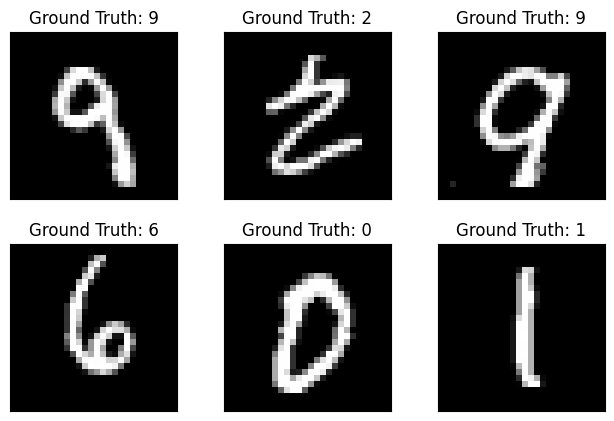

In [4]:
fig = plt.figure()
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.tight_layout()
    plt.imshow(data[i][0], cmap='gray', interpolation='none')
    plt.title("Ground Truth: {}".format(targets[i]))
    plt.xticks([])
    plt.yticks([])

## 1) Convolutional Neural Network
In this exercise, we will implement a Convolutional Neural Network inspired by the LeNet-5 architecture.

![](lenet.png)
Source: http://vision.stanford.edu/cs598_spring07/papers/Lecun98.pdf

Unlike the original architecture, for the subsampling we will use Averarge Pooling, and our output layer will be another Linear layer.

## 1.1) Implement the LeNet-5 inspired architecture in PyTorch
The architecture should consist of the following layers:
- Convolutional layer with  6 neurons, a 5x5 kernel, and stride 1, followed by a tanh function
- Average pooling layer with a 2x2 window size
- Convolutional layer with 16 neurons, a 5x5 kernel, and stride 1, followed by a tanh function
- Average pooling layer with a 2x2 window size
- Fully connected layer with 120 neurons
- Fully connected layer with 84 neurons

In [20]:
class LeNet5(Module):
    def __init__(self):
        super(LeNet5, self).__init__()

        # Convolutional layers
        self.conv1 = Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1)
        self.tanh1 = Tanh()
        self.avgpool1 = AvgPool2d(kernel_size=2, stride=2)

        self.conv2 = Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1)
        self.tanh2 = Tanh()
        self.avgpool2 = AvgPool2d(kernel_size=2, stride=2)

        # Fully connected layers
        # Adjust the in_features according to your input image size
        self.fc1 = Linear(16*4*4, 120)
        self.tanh3 = Tanh()

        self.fc2 = Linear(120, 84)
        self.tanh4 = Tanh()

        # Assuming 10 output classes
        self.fc3 = Linear(84, 10) 

    def forward(self, x):
        x = self.avgpool1(self.tanh1(self.conv1(x)))
        x = self.avgpool2(self.tanh2(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = self.tanh3(self.fc1(x))
        x = self.tanh4(self.fc2(x))
        x = self.fc3(x)
        return log_softmax(x,dim=1)

    
def train(
    model:Module, 
    train_loader:DataLoader, 
    optimizer: SGD, 
    epoch:int, 
    log_interval = 50
):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        # Reset the gradients
        optimizer.zero_grad() 
        
        # Feed the data through the model
        output = model(data) 
        
        # Compute the negative log-likelihood loss
        loss = nll_loss(output, target) 
        
        # Backward propagate the gradients
        loss.backward() 
        
        # Perform an update step using the optimizer
        optimizer.step() 
        
        # Log
        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))


def test(model:Module, test_loader:DataLoader):
    # Set model to evaluation mode
    model.eval()
    
    test_loss = 0
    correct = 0
    
    # Don't accumulate gradients
    with torch.no_grad():
        for data, target in test_loader:
            # Feed the data through the model
            output = model(data)
            
            # Sum up batch loss
            test_loss += nll_loss(output, target, reduction='sum').item()  
            
            # The prediction is the index of the max log-probability
            pred = output.argmax(dim=1, keepdim=True)  
            
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.3f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)
    ))

Train the network for 10 epochs using SGD with a `learning_rate = 0.01` and `momentum = 0.9`.
You should be able to get a 99% accuracy.

In [21]:
model = LeNet5()
optimizer = SGD(model.parameters(), lr=0.01, momentum=0.9)

epochs = 10
for epoch in range(1, epochs + 1):
    train(model, train_loader, optimizer, epoch, log_interval=50)
    test(model, test_loader)

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.298249
Train Epoch: 1 [3200/60000 (5%)]	Loss: 1.844327
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.789652
Train Epoch: 1 [9600/60000 (16%)]	Loss: 0.537064
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.225870
Train Epoch: 1 [16000/60000 (27%)]	Loss: 0.488579
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.251208
Train Epoch: 1 [22400/60000 (37%)]	Loss: 0.350907
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.414299
Train Epoch: 1 [28800/60000 (48%)]	Loss: 0.106500
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.287443
Train Epoch: 1 [35200/60000 (59%)]	Loss: 0.126203
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.159577
Train Epoch: 1 [41600/60000 (69%)]	Loss: 0.237468
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.113885
Train Epoch: 1 [48000/60000 (80%)]	Loss: 0.182232
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.102505
Train Epoch: 1 [54400/60000 (91%)]	Loss: 0.076539
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.355178

Test set: Average loss: 0.1370, Accuracy: 9600/10000 (96.0

# 2) Limited labelled data
In the previous case, we had plenty of training data (60000 example) to get good performance.
What if we had much less data (100 examples)?

In [22]:
# Generate new datasets
mini_train_size = 100

mini_train_data, rest_train_data = random_split(  
    train_data, [mini_train_size, len(train_data) - mini_train_size]
)

# Our small labelled dataset
mini_train_loader = DataLoader(
    mini_train_data,
    batch_size = 64,
    shuffle=True,
)

# Our larger, unlabbeled dataset
# We will act as if we didn't have labels for this data
rest_train_loader = DataLoader(
    rest_train_data,
    batch_size = 64,
    shuffle=True,
)

## 2.1) Rerun the LeNet-5 network with only 100 examples total
Run it for 200 epochs using the `mini_train_loader`.
What is the test accuracy?

In [23]:
model = LeNet5()
optimizer = SGD(model.parameters(), lr=0.01, momentum=0.9)

epochs = 200
for epoch in range(1, epochs + 1):
    train(model, mini_train_loader, optimizer, epoch)
    if epoch % 10 == 0:
        test(model, test_loader)

Train Epoch: 1 [0/100 (0%)]	Loss: 2.304239
Train Epoch: 2 [0/100 (0%)]	Loss: 2.307509
Train Epoch: 3 [0/100 (0%)]	Loss: 2.304190
Train Epoch: 4 [0/100 (0%)]	Loss: 2.291342
Train Epoch: 5 [0/100 (0%)]	Loss: 2.284951
Train Epoch: 6 [0/100 (0%)]	Loss: 2.267784
Train Epoch: 7 [0/100 (0%)]	Loss: 2.260367
Train Epoch: 8 [0/100 (0%)]	Loss: 2.242244
Train Epoch: 9 [0/100 (0%)]	Loss: 2.224977
Train Epoch: 10 [0/100 (0%)]	Loss: 2.216283

Test set: Average loss: 2.2323, Accuracy: 2400/10000 (24.000%)

Train Epoch: 11 [0/100 (0%)]	Loss: 2.192221
Train Epoch: 12 [0/100 (0%)]	Loss: 2.190144
Train Epoch: 13 [0/100 (0%)]	Loss: 2.135660
Train Epoch: 14 [0/100 (0%)]	Loss: 2.137449
Train Epoch: 15 [0/100 (0%)]	Loss: 2.107301
Train Epoch: 16 [0/100 (0%)]	Loss: 2.067964
Train Epoch: 17 [0/100 (0%)]	Loss: 2.072582
Train Epoch: 18 [0/100 (0%)]	Loss: 1.996844
Train Epoch: 19 [0/100 (0%)]	Loss: 1.931428
Train Epoch: 20 [0/100 (0%)]	Loss: 1.909338

Test set: Average loss: 1.9968, Accuracy: 3320/10000 (33.200%)


We end with ≈67% accuracy. NB: due to the small size of training data, the variance of the results may be high.

## 3) Implement an Autoencoder and train it on the unlabelled data
Though we have very little labelled training data, we may have plenty of unlabelled data available (`rest_data_loader`). 
This data can be utilised in many ways; one such way is by using an Autoencoder.

Implement an autoencoder with the following layers:
- Encoder:
    - Convolutional layer with  6 neurons, a 5x5 kernel, and stride 1, followed by a tanh function
    - Average pooling layer with a 2x2 window size
    - Convolutional layer with 16 neurons, a 5x5 kernel, and stride 1, followed by a tanh function
    - Average pooling layer with a 2x2 window size
    - Fully connected layer with 120 neurons
- Decoder:
    - Fully connected layer with 256 neurons
    - Upsample layer with scale-factor 2
    - Transpose convolution with 16 neurons, a 5x5 kernel, and stride 1, followed by a tanh function
    - Upsample layer with scale-factor 2
    - Transpose convolution with 6 neurons, a 5x5 kernel, and stride 1, followed by a tanh function
    
Use the given training code to train check that the implementation works and loss is reduced.

In [39]:
class AutoEncoder(Module):
    def __init__(self):
        super(AutoEncoder, self).__init__()
        
        # Encoder
        self.encoder_conv = Sequential(
            Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1),
            Tanh(),
            AvgPool2d(kernel_size=2, stride=2),
            Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1),
            Tanh(),
            AvgPool2d(kernel_size=2, stride=2)
        )
        
        self.encoder_fc = Linear(16*4*4, 120) 
        
        # Decoder
        self.decoder_fc = Linear(120, 256)
        self.decoder_conv = Sequential(
            Upsample(scale_factor=2),
            ConvTranspose2d(in_channels=16, out_channels=6, kernel_size=5, stride=1),
            Tanh(),
            Upsample(scale_factor=2),
            ConvTranspose2d(in_channels=6, out_channels=1, kernel_size=5, stride=1),
            Tanh()
        )

    def forward(self, x):
        x = self.encoder_conv(x)
        x = torch.flatten(x,1)
        x = self.encoder_fc(x)
        
        x = self.decoder_fc(x)
        x = x.view(-1, 16, 4, 4)
 
        x = self.decoder_conv(x)
        
        return x


def train_autoencoder(
    model:Module, 
    train_loader:DataLoader, 
    optimizer: SGD, 
    epoch:int, 
    log_interval = 50
):
    model.train()
    for batch_idx, (data, _) in enumerate(train_loader):
        # Reset the gradients
        optimizer.zero_grad() 
        
        # Feed the data through the model
        output = model(data) 
        
        # Compute the negative log-likelihood loss
        loss = mse_loss(output, data) 
        
        # Backward propagate the gradients
        loss.backward() 
        
        # Perform an update step using the optimizer
        optimizer.step() 
        
        # Log
        if batch_idx % log_interval == 0:
            print('AE Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))


In [40]:
# Check that the auto-encoder works by training it and checking that the loss is reduced

ae_model = AutoEncoder()
optimizer = SGD(ae_model.parameters(), lr=0.01, momentum=0.9)

batch_size = 64
epochs = 1
for epoch in range(1, epochs + 1):
    train_autoencoder(ae_model, rest_train_loader, optimizer, epoch, log_interval=50)

AE Train Epoch: 1 [0/59900 (0%)]	Loss: 1.003466
AE Train Epoch: 1 [3200/59900 (5%)]	Loss: 0.673205
AE Train Epoch: 1 [6400/59900 (11%)]	Loss: 0.590437
AE Train Epoch: 1 [9600/59900 (16%)]	Loss: 0.548547
AE Train Epoch: 1 [12800/59900 (21%)]	Loss: 0.505048
AE Train Epoch: 1 [16000/59900 (27%)]	Loss: 0.486890
AE Train Epoch: 1 [19200/59900 (32%)]	Loss: 0.521257
AE Train Epoch: 1 [22400/59900 (37%)]	Loss: 0.464846
AE Train Epoch: 1 [25600/59900 (43%)]	Loss: 0.459806
AE Train Epoch: 1 [28800/59900 (48%)]	Loss: 0.466882
AE Train Epoch: 1 [32000/59900 (53%)]	Loss: 0.468805
AE Train Epoch: 1 [35200/59900 (59%)]	Loss: 0.460659
AE Train Epoch: 1 [38400/59900 (64%)]	Loss: 0.480422
AE Train Epoch: 1 [41600/59900 (69%)]	Loss: 0.441255
AE Train Epoch: 1 [44800/59900 (75%)]	Loss: 0.467604
AE Train Epoch: 1 [48000/59900 (80%)]	Loss: 0.448601
AE Train Epoch: 1 [51200/59900 (85%)]	Loss: 0.477356
AE Train Epoch: 1 [54400/59900 (91%)]	Loss: 0.457340
AE Train Epoch: 1 [57600/59900 (96%)]	Loss: 0.461696


## Demo: Using the Autoencoder in a multi-task learning setup to improve classification performance.
Multitask learning is the learning of multiple tasks in parallel.
What we do here is to integrate the encoding layers of the autoencoder as layers in the LeNet5. We can then train the autoencoder and classification network in parallel in order to improve performance on the classification task.

The code below assumes that you have a working implementation of the Autoencoder.

In [37]:
class AutoEncoderLeNet5(Module):
    def __init__(self, autoencoder):
        super(AutoEncoderLeNet5, self).__init__()
        self.autoencoder = autoencoder
        self.fc2 = Linear(in_features=120, out_features=84)
        self.fc3 = Linear(in_features=84, out_features=10)

    def forward(self, x):
        x = self.autoencoder.encoder_conv(x)
        x = flatten(x, 1)
        x = self.autoencoder.encoder_fc(x)
        x = tanh(self.fc2(x))
        x = tanh(self.fc3(x))
        return log_softmax(x, dim=1)
    
def train_hybrid(
    model:Module, 
    ae_model:Module,
    labelled_loader:DataLoader,
    unlabelled_loader:DataLoader,
    optimizer: SGD, 
    labelled_steps:int,
    unlabelled_steps:int,
    epoch:int, 
    log_interval = 50
):
    ae_model.train()
    model.train()
    labelled_iter = iter(labelled_loader)
    unlabelled_iter = iter(unlabelled_loader)
    for step in range(1, unlabelled_steps+1):
        if step % labelled_steps == 0:
            labelled_iter = iter(labelled_loader)
            
        data_l, target = next(labelled_iter)
        data_u, _ = next(unlabelled_iter)
        
        # Reset the gradients
        optimizer.zero_grad() 
        
        # Feed the data through the model
        output_u = ae_model(data_u)
        output_l = model(data_l)
        
        # Compute the negative log-likelihood loss
        loss_l = nll_loss(output_l, target) 
        loss_u = mse_loss(output_u, data_u) 
        
        # Backward propagate the gradients
        loss_u.backward() 
        loss_l.backward() 
        
        # Perform an update step using the optimizer
        optimizer.step() 
        
        # Log
        if step % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tULoss: {:.6f} \t LLoss: {:.6f}'.format(
                epoch, step * unlabelled_steps, len(unlabelled_loader.dataset),
                100. * step / unlabelled_steps, loss_u.item(), loss_l.item()))

In [38]:
ae_model = AutoEncoder()
hybrid_model = AutoEncoderLeNet5(ae_model)
optimizer = SGD(ae_model.parameters(), lr=0.01, momentum=0.9)

batch_size = 64
labelled_steps = ceil(len(mini_train_data) / batch_size)
unlabelled_steps = ceil(len(rest_train_data) / batch_size)
epochs = 5
for epoch in range(1, epochs + 1):
    train_hybrid(hybrid_model, ae_model, mini_train_loader, rest_train_loader, optimizer, labelled_steps, unlabelled_steps, epoch, log_interval=50)
    test(hybrid_model, test_loader)

/var/folders/65/1n30j6qx5qg79xwsb8vr4v1c0000gn/T/ipykernel_22478/890316145.py:47: UserWarning: Using a target size (torch.Size([64, 1, 28, 28])) that is different to the input size (torch.Size([64, 6, 28, 28])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_u = mse_loss(output_u, data_u)


Train Epoch: 1 [46800/59900 (5%)]	ULoss: 0.805939 	 LLoss: 2.014900
Train Epoch: 1 [93600/59900 (11%)]	ULoss: 0.629960 	 LLoss: 1.684643
Train Epoch: 1 [140400/59900 (16%)]	ULoss: 0.559273 	 LLoss: 1.531859
Train Epoch: 1 [187200/59900 (21%)]	ULoss: 0.551089 	 LLoss: 1.465786
Train Epoch: 1 [234000/59900 (27%)]	ULoss: 0.540579 	 LLoss: 1.404793
Train Epoch: 1 [280800/59900 (32%)]	ULoss: 0.509921 	 LLoss: 1.356006
Train Epoch: 1 [327600/59900 (37%)]	ULoss: 0.478694 	 LLoss: 1.341611
Train Epoch: 1 [374400/59900 (43%)]	ULoss: 0.487053 	 LLoss: 1.317141
Train Epoch: 1 [421200/59900 (48%)]	ULoss: 0.470391 	 LLoss: 1.269723
Train Epoch: 1 [468000/59900 (53%)]	ULoss: 0.497502 	 LLoss: 1.259322
Train Epoch: 1 [514800/59900 (59%)]	ULoss: 0.466019 	 LLoss: 1.232660
Train Epoch: 1 [561600/59900 (64%)]	ULoss: 0.508399 	 LLoss: 1.225732
Train Epoch: 1 [608400/59900 (69%)]	ULoss: 0.473161 	 LLoss: 1.209239
Train Epoch: 1 [655200/59900 (75%)]	ULoss: 0.454955 	 LLoss: 1.196993
Train Epoch: 1 [702000/

/var/folders/65/1n30j6qx5qg79xwsb8vr4v1c0000gn/T/ipykernel_22478/890316145.py:47: UserWarning: Using a target size (torch.Size([60, 1, 28, 28])) that is different to the input size (torch.Size([60, 6, 28, 28])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_u = mse_loss(output_u, data_u)



Test set: Average loss: 1.4033, Accuracy: 8038/10000 (80.380%)

Train Epoch: 2 [46800/59900 (5%)]	ULoss: 0.478659 	 LLoss: 1.145429
Train Epoch: 2 [93600/59900 (11%)]	ULoss: 0.446893 	 LLoss: 1.125535
Train Epoch: 2 [140400/59900 (16%)]	ULoss: 0.450010 	 LLoss: 1.126877
Train Epoch: 2 [187200/59900 (21%)]	ULoss: 0.425148 	 LLoss: 1.119697
Train Epoch: 2 [234000/59900 (27%)]	ULoss: 0.436357 	 LLoss: 1.115356
Train Epoch: 2 [280800/59900 (32%)]	ULoss: 0.424667 	 LLoss: 1.107917
Train Epoch: 2 [327600/59900 (37%)]	ULoss: 0.413431 	 LLoss: 1.118180
Train Epoch: 2 [374400/59900 (43%)]	ULoss: 0.450278 	 LLoss: 1.100441
Train Epoch: 2 [421200/59900 (48%)]	ULoss: 0.464147 	 LLoss: 1.087892
Train Epoch: 2 [468000/59900 (53%)]	ULoss: 0.419453 	 LLoss: 1.089894
Train Epoch: 2 [514800/59900 (59%)]	ULoss: 0.396341 	 LLoss: 1.086331
Train Epoch: 2 [561600/59900 (64%)]	ULoss: 0.427860 	 LLoss: 1.099127
Train Epoch: 2 [608400/59900 (69%)]	ULoss: 0.431084 	 LLoss: 1.093188
Train Epoch: 2 [655200/59900

You should expect an classification accuracy boost of 10-15% compared to using only the `mini_train_loader`.

## Exam exercise

In [1]:
import numpy as np

F = np.array([[-1, 0, 1],
              [-2, 0, 2],
              [-1, 0, 1]])


x_1 = np.array([[1, 2, 3, 4],
                [4, 5, 7, 8],
                [9, 10, 11, 12]])

from scipy.signal import convolve2d

# Applying the convolution operation
result = convolve2d(x_1, F, mode='valid')  # 'valid' mode for no padding
result


array([[-10, -10]])

In [22]:
x_2 = np.random.randint(0, 10, (224, 224))  # 224x244 matrix

def convolution_2d(input_tensor, filter_kernel, stride):
    M, N = input_tensor.shape
    K, _ = filter_kernel.shape
    output_shape = ((M - K) // stride + 1, (N - K) // stride + 1)
    result = np.zeros(output_shape)

    for m in range(output_shape[0]):
        for n in range(output_shape[1]):
            for i in range(K):
                for j in range(K):
                    result[m, n] += input_tensor[stride * n - i, stride * m - j] * filter_kernel[i, j]

    return result.shape

convolution_2d(x_2, F, 2)

(111, 111)

In [6]:
from scipy.signal import convolve2d

result = convolve2d(x_1, F, mode='same') # zero padding
result

array([[  0,  -7,  -7,   4],
       [-10, -10, -10,  16],
       [-16,  -7,  -7,  20]])

In [17]:
x_2 = np.random.randint(0, 10, (224, 224))  # 224x244 matrix

result = convolve2d(x_2, F, mode='valid')  # 'valid' mode for no padding
result.shape


(222, 222)

# Add padding 

In [7]:
import numpy as np
from scipy.signal import convolve2d

# Define the filter F and input X_1
F = np.array([[-1, 0, 1],
              [-2, 0, 2],
              [-1, 0, 1]])

X_1 = np.array([[1, 2, 3, 4],
                [4, 5, 7, 8],
                [9, 10, 11, 12]])

# Decide the padding size, e.g., 1 pixel on all sides
padding_size = 1

# Pad the input matrix
X_1_padded = np.pad(X_1, padding_size, mode='constant', constant_values=0)

# Apply the convolution operation with 'valid' mode
result = convolve2d(X_1_padded, F, mode='valid')
result


array([[ -9,  -7,  -7,  13],
       [-22, -10, -10,  28],
       [-25,  -7,  -7,  29]])